<a href="https://colab.research.google.com/github/sanit15/pytorch/blob/main/01_Pytorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PyTorch Workflow

In [1]:
what_are_we_covering = {1: "data (prepare and load)",
                        2: "build model",
                        3: "making predictions",
                        4: "making predictions and evaluating a model(inference)",
                        5: "saving and loading a model",
                        6: "putting it all together"}
what_are_we_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'making predictions',
 4: 'making predictions and evaluating a model(inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # all modules for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

##1. Data(preparing and loading)
Data can vbe anything...

* Excel spreadsheets
* Images of any kind
* Audio

Machine learning is a game of 2 parts
* get data into numerical rep
* build a model tht can representation and pattern

using `linear regression` to create known data.
create a straight line with known **parameter**

In [3]:
#create  known parameter
weight = 0.7
bias = 0.3

#create
start = 0
end =1
step =0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

###spliting data into training and test sets (onr of the most iportant concepts in ml)
Lets create a traing and test set

In [4]:
#create a train/test split
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test  = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plt_prediction(train_data = X_train, train_label = y_train, test_data = X_test, test_labels = y_test, predictions = None):
  """
  plots training data, test data and compares predictions
  """
  plt.figure(figsize=(10,7))
  #PLOT TRAINING DATA
  plt.scatter(train_data,train_label,c="b",s=4,label="training data")

  #PLOT TEST DATA
  plt.scatter(test_data,test_labels,c="g",s=4,label="test data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c= 'r', s=4, label = "Predictions")

  #show the legend
  plt.legend(prop={"size":14})

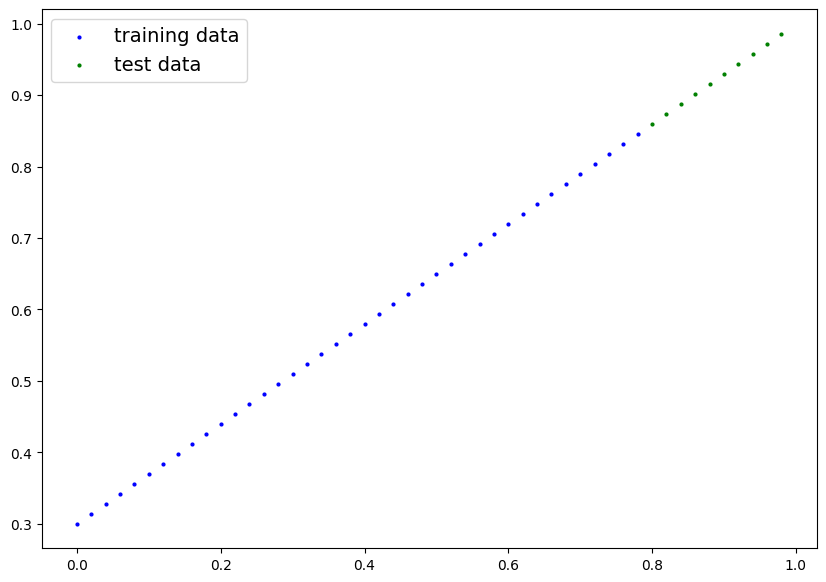

In [6]:
plt_prediction()

## 2. Build Model

Our first PyTorch Model
What is our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & the bais value we used to create the data)

How does it do so?

Through 2 main algorithms:
1. Gradient Dscent
2. Backpropagation

In [7]:
from torch import nn
#create Linear regression model class
class LinearRegressionModel(nn.Module): ## <- base class almost all in pytorch models
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # <- start with random weight and try to adjust it to the ideal weight
                                            requires_grad = True,
                                            dtype = torch.float))
    self.bais = nn.Parameter(torch.randn(1, # <- start with a random bias and adjust it to the ideal bias
                                         requires_grad = True,
                                         dtype = torch.float))
    # Forward method to define the computatuon in model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # x <- input data
    return self.weights*x + self.bais

### Pytorch model building essentials

* torch.nn - contains all of the building for computational graphs(nn can be considered a computational graph)
* torch.nn.Parameter - what parameters shoulf our model try and learmn often a Pytorch layer from torch.nn will s=et these for us
* torch.nn.Module - base class for all nn modules, if you subclass it, you should overrite forward()
* torch.optim - this where the optimizers in PyTorch live, they will help in gradient descent
* def forward() - All methods in nn subcklass requires you to overwrite forward, this method defines what happens in the forward computation

###Checking the contents of our Pytorch model

we can check our model parameter ir whts inside our model using `.parameters()`

In [8]:
#create a random seed
torch.manual_seed(42)

#create an instanse of the modeel(thsi is a subclass of nn.Module)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
#List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bais', tensor([0.1288]))])

###making prediction using torch.inference_mode()

to CHECK MODEL `predictive power` lets see how well it predicts `y_test` based on `x_test`

When we pass the data through the model, its going to run it through the forward() method

In [10]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [11]:
#make prediction model
with torch.inference_mode():
  y_preds = model_0(X_test)
# can also do something similar with torch.no_grad(), however, inference_mode is preserved
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

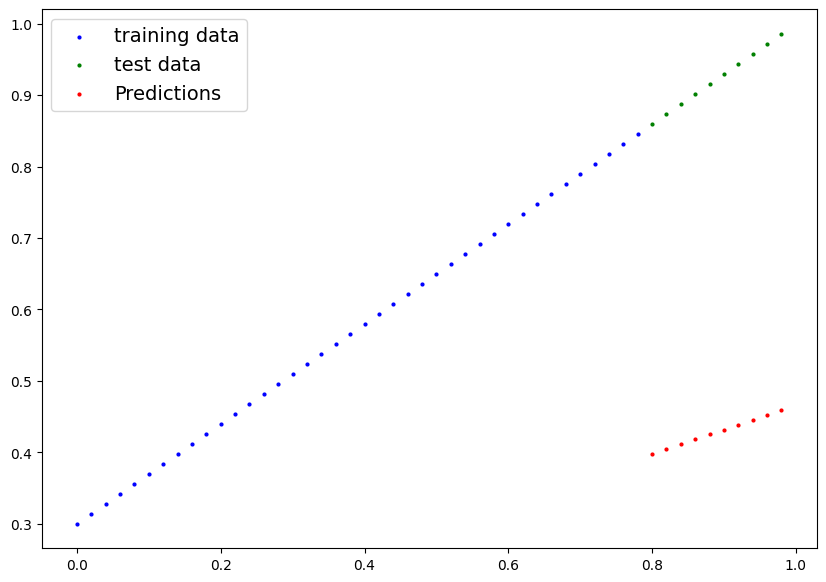

In [12]:
plt_prediction(predictions=y_preds)

# 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (may be random) to some *known* parameters

in other words, from poor to a better representation of data

One way to measure how ppor the model is to use a loss funtion.

Things we need to train:

* **Loss function** - A function to measure how wrong your model's prediction are to the ideal outputs.
* **Optimizer** - Takes into account the loss of a model and adjusts the model's parameters, to impove the loss function.
* **params** - the modelparameters youd like to optimize =, example `params = model_0.parameters`
* **lr**(learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step

And specifically for PyTorch, we need:

* Training loop
* Testing loop

In [13]:
#Setup Loss function
loss_fn = nn.L1Loss()

#Setup Optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01) #lr = learning rate = possibly the most important learning hyperparameter


**Q:** Which loss function and optimizer should be used?

**A:** This will be problem specific. But with experience, you'll get an idea of what works and doesnt with your particulat problem set.

Example: for classification problems like classifying whether a photo is of a dog or cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).



### building a training loop in Pytorch

### Building a training loop ( and a testing loop) in PyTorch

A couple of things we need in a training loop:0. Loop through the data
1. Forward Pass (this involoves data moving through our model's
`forward()` functions) - also callled forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizers zero grad
4. Loss backwards - now backwards through the network to calculate the gradients of the parameters of our model with respect to the loss (**backpropagation**).
5. Optimizer step - use the optimizer to adjust our models parameters to try and improve the loss (**gradient descent**)

In [14]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [15]:
torch.manual_seed(42)

# An epoch is one loop through the data...
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

#loop through the data

### Training
# 0. Loop throuth the data
for epoch in range(epochs):
  #Set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to requires gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  #print(f"Loss: {loss}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backwards (backpropagation)
  loss.backward()

  # 5. Optimizer step
  optimizer.step() # by default it accumulates through the loop so... we have to zero themabove in step 3 for the next iteration of the loop

  ###Testing
  model_0.eval() # turns off setting s not needed for evaluation
  with torch.inference_mode(): # turns off gradient tracking

    # 1. Forward pass
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f'Epoch: {epoch} | loss: {test_loss} | Test_loss{test_loss} ')

    # print model state_dict()
    print(model_0.state_dict())

Epoch: 0 | loss: 0.48106518387794495 | Test_loss0.48106518387794495 
OrderedDict({'weights': tensor([0.3406]), 'bais': tensor([0.1388])})
Epoch: 10 | loss: 0.3463551998138428 | Test_loss0.3463551998138428 
OrderedDict({'weights': tensor([0.3796]), 'bais': tensor([0.2388])})
Epoch: 20 | loss: 0.21729660034179688 | Test_loss0.21729660034179688 
OrderedDict({'weights': tensor([0.4184]), 'bais': tensor([0.3333])})
Epoch: 30 | loss: 0.14464017748832703 | Test_loss0.14464017748832703 
OrderedDict({'weights': tensor([0.4512]), 'bais': tensor([0.3768])})
Epoch: 40 | loss: 0.11360953003168106 | Test_loss0.11360953003168106 
OrderedDict({'weights': tensor([0.4748]), 'bais': tensor([0.3868])})
Epoch: 50 | loss: 0.09919948130846024 | Test_loss0.09919948130846024 
OrderedDict({'weights': tensor([0.4938]), 'bais': tensor([0.3843])})
Epoch: 60 | loss: 0.08886633068323135 | Test_loss0.08886633068323135 
OrderedDict({'weights': tensor([0.5116]), 'bais': tensor([0.3788])})
Epoch: 70 | loss: 0.0805937647

In [16]:
import numpy as np
epoch_count_array = np.array(epoch_count)
loss_values_array = np.array(torch.tensor(loss_values).numpy())
test_loss_values_array = np.array(test_loss_values)

/tmp/ipykernel_11975/4104489510.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss_values_array = np.array(torch.tensor(loss_values).numpy())


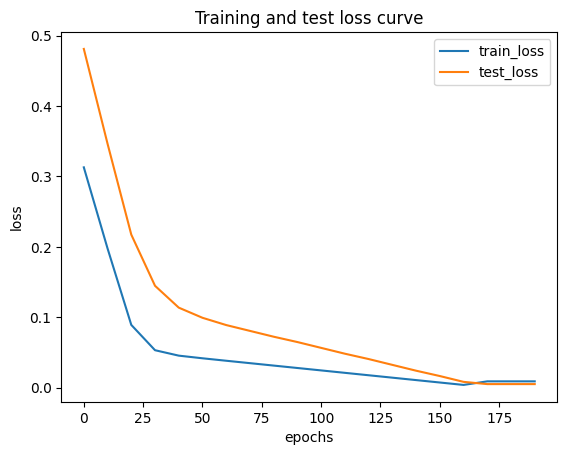

In [17]:
#plot the loss curves
plt.plot(epoch_count_array, loss_values_array, label = "train_loss")
plt.plot(epoch_count, test_loss_values_array, label = "test_loss")
plt.title("Training and test loss curve")
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()

In [18]:
weight, bias

(0.7, 0.3)

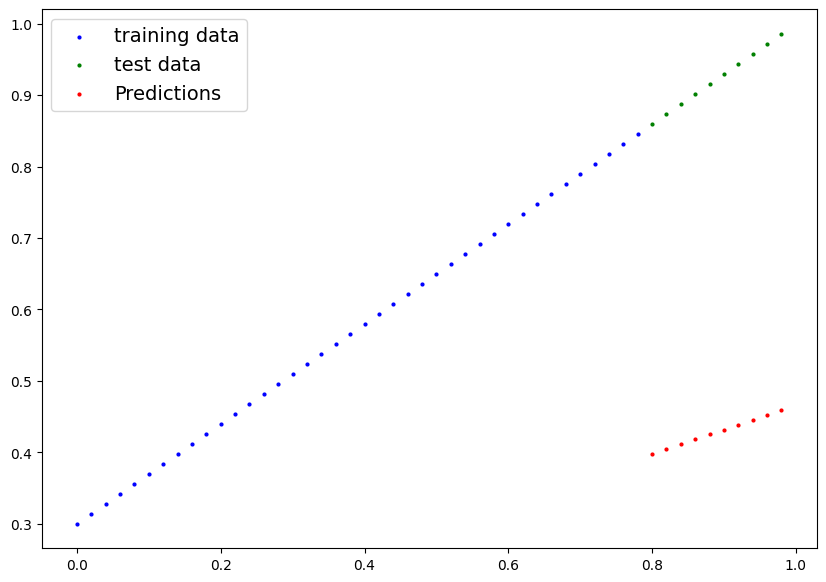

In [19]:
plt_prediction(predictions=y_preds)

In [20]:
with torch.inference_mode():
  y_preds1 = model_0(X_test)

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bais', tensor([0.3093]))])

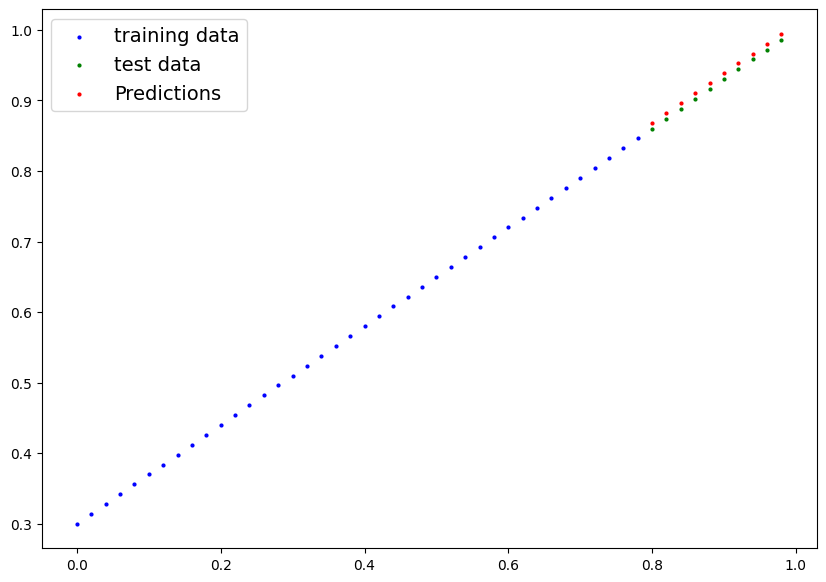

In [22]:
plt_prediction(predictions=y_preds1)

# Saving a model in PyTorch

There are three main methods you should know about for saving and loading models in pytorch.

1. `torch.save()` - allow you to save a python object in pickle format.

2. `torch.load()` - allows you to load a saved PyTorch object.
3. `torch.nn,Module.load_state_dict()` - this allows you to load a models saved state dictionary

In [23]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bais', tensor([0.3093]))])

In [24]:
#saving our Pytorch model
from pathlib import Path

# 1. create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

#2. create odel save path
MODEL_NAME = "01_pytorch_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)



Saving model to: models/01_pytorch_model_0.pth


In [25]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1981 Jul  2 13:15 01_pytorch_model_0.pth


# loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bais', tensor([0.3093]))])

In [27]:
# TO load in a saved stae_dict we have to intantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [28]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bais', tensor([0.3093]))])

In [29]:
# MAKE SOME PREDICTIONS WITH OUR LOADED MODEL
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [30]:
# Compare loaded model predswith original model preds
y_preds1 == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 6. Putting it all together

Lets go back through the steps above and see it all in one place

In [31]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.11.0+cu128'

Create device-agnostic code.

This means if we've go access to the GPU, our code will use it (for potential faster computing)

In [32]:
#Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 6.1 Data

In [57]:
#CREATE SOME DATA USING LINEAR REGRESSION MODEL y = bx + a
weight = 0.7
bais = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim = 1) # without unsqueeze errors will pop up
y = weight * X + bais
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [58]:
#split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

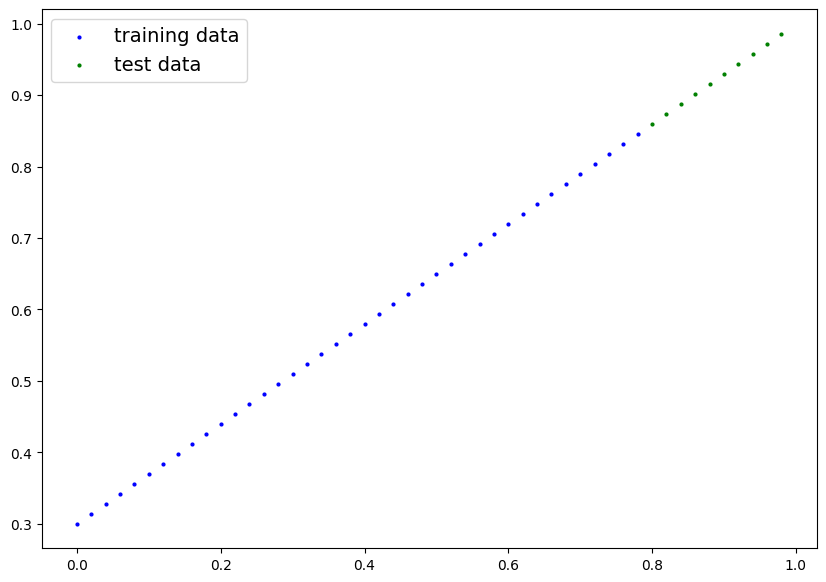

In [59]:
plt_prediction(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu())

## 6.2 Building pytorch linear model

In [60]:
# Create a linear model by subclassing nn.Moduele
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters / also called: linear transform, probing layer, fully connected
    self.linear_layer = nn.Linear(in_features = 1,
                                  out_features = 1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [61]:
# Set the model to use the target device
next(model_1.parameters()).device

device(type='cpu')

In [62]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [63]:
# Setup loss function
loss_fn_1 = nn.L1Loss()

# Setup our optimizer
optimizer_1 = torch.optim.SGD(params = model_1.parameters(),lr = 0.01)

In [64]:
# lets write a training loop
torch.manual_seed(42)

epochs = 200

# put data on same device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#loop through the data

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred_1 = model_1(X_train)

  # 2. Calculate the loss
  Loss1 = loss_fn_1(y_pred_1, y_train)

  # 3. Optimizers zero grad
  optimizer_1.zero_grad()

  # 4. Perform backpropagation
  Loss1.backward()

  # 5. Optimizer step
  optimizer_1.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)

    test_loss = loss_fn_1(test_pred, y_test)

    #print out whats happening

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss value: {Loss1} | test loss: {test_loss}")


Epoch: 0 | Loss value: 0.5551779270172119 | test loss: 0.5739762187004089
Epoch: 10 | Loss value: 0.4399681091308594 | test loss: 0.4392664134502411
Epoch: 20 | Loss value: 0.3247582018375397 | test loss: 0.30455657839775085
Epoch: 30 | Loss value: 0.20954833924770355 | test loss: 0.16984669864177704
Epoch: 40 | Loss value: 0.09433844685554504 | test loss: 0.03513690456748009
Epoch: 50 | Loss value: 0.023886388167738914 | test loss: 0.04784907028079033
Epoch: 60 | Loss value: 0.019956795498728752 | test loss: 0.045803118497133255
Epoch: 70 | Loss value: 0.016517987474799156 | test loss: 0.037530567497015
Epoch: 80 | Loss value: 0.013089174404740334 | test loss: 0.02994490973651409
Epoch: 90 | Loss value: 0.009653178043663502 | test loss: 0.02167237363755703
Epoch: 100 | Loss value: 0.006215683650225401 | test loss: 0.014086711220443249
Epoch: 110 | Loss value: 0.00278724217787385 | test loss: 0.005814164876937866
Epoch: 120 | Loss value: 0.0012645035749301314 | test loss: 0.01380180101

In [65]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [66]:
weight, bais

(0.7, 0.3)

In [67]:
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)

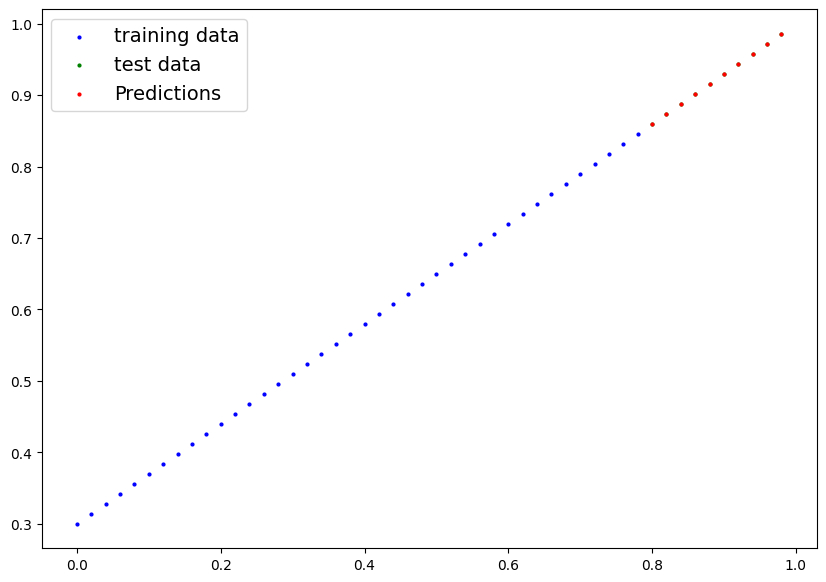

In [68]:
plt_prediction(predictions = y_preds.cpu())

## 6.5 saving and loading trained model

In [73]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_model_1.pth


In [74]:
# Load pytorch model

# Crete a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [75]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [76]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [77]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [79]:
# evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode( ):
  loaded_model_1_preds = loaded_model_1(X_test)
loaded_model_1_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')